In [ ]:
# Exploratory Data Analysis — Online Retail Dataset

## Objective
## Analyze transactional retail data to identify patterns, data issues, and business insights.

## Dataset Description
## This dataset contains transaction-level retail data including products, customers, and revenue.

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [27]:
df = pd.read_csv("online_retail.csv", encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


(541909, 8)

In [ ]:
## The dataset contains transactional records with both numerical and categorical features. Initial
## inspection suggests the presence of missing values and potential inconsistencies that require cleaning.

In [29]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
## Missing values are present in the CustomerID column, limiting the ability to
## fully track customer-level behavior. These records will be removed for analysis.

In [30]:
df = df.dropna(subset=['CustomerID'])

df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
## Invalid records such as missing customer identifiers and negative values (returns) were removed.
## A new revenue column was created to support business analysis.

In [31]:
df['Revenue'].describe()

print("Mean:", df['Revenue'].mean())
print("Median:", df['Revenue'].median())
print("Std Dev:", df['Revenue'].std())
print("Skewness:", df['Revenue'].skew())

Mean: 22.396999889415003
Median: 11.8
Std Dev: 309.0710414139642
Skewness: 451.4431818297993


In [ ]:
## Revenue is highly skewed, indicating the presence of a small number of high-value transactions dominating the dataset.

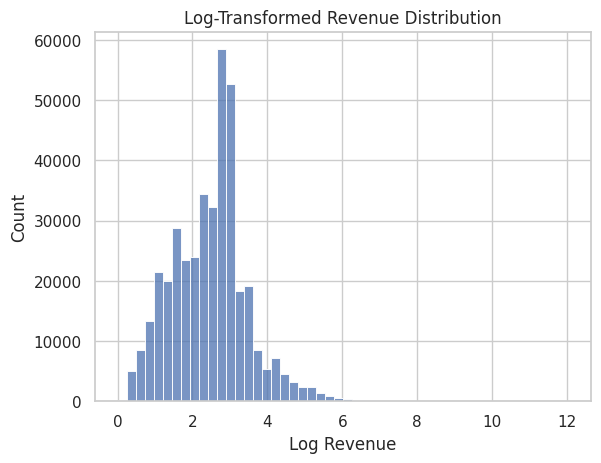

In [32]:
sns.histplot(np.log1p(df['Revenue']), bins=50)
plt.title("Log-Transformed Revenue Distribution")
plt.xlabel("Log Revenue")
plt.show()

In [ ]:
## The log transformation reveals a more interpretable distribution, confirming that most
## transactions are low-value while a few are significantly larger.

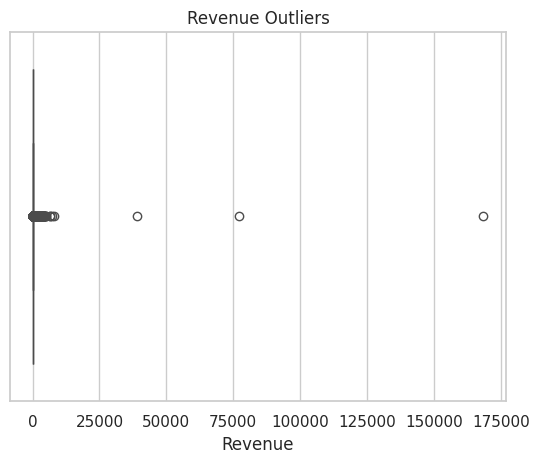

In [33]:
sns.boxplot(x=df['Revenue'])
plt.title("Revenue Outliers")
plt.show()

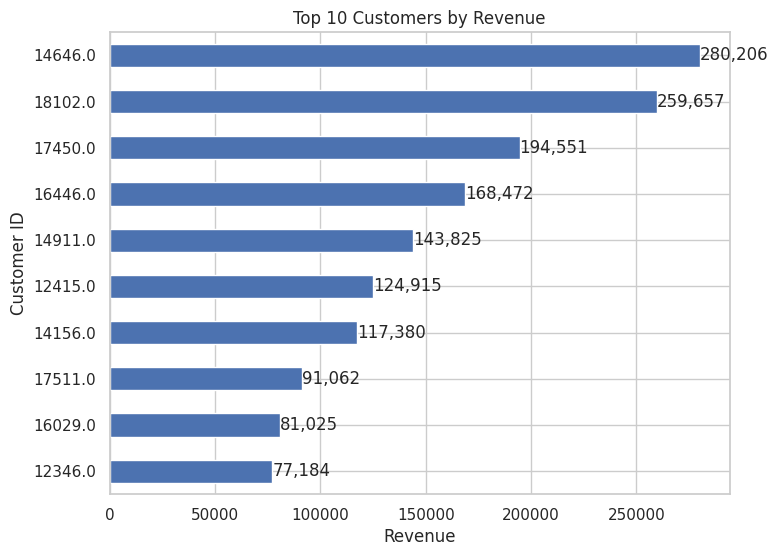

In [34]:
top_customers = df.groupby('CustomerID')['Revenue'] \
                  .sum() \
                  .sort_values(ascending=False) \
                  .head(10) \
                  .round(0)

fig, ax = plt.subplots(figsize=(8,6))

top_customers.sort_values().plot(kind='barh', ax=ax)

for i, v in enumerate(top_customers.sort_values()):
    ax.text(v, i, f"{int(v):,}", va='center')

ax.set_title("Top 10 Customers by Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Customer ID")

plt.show()

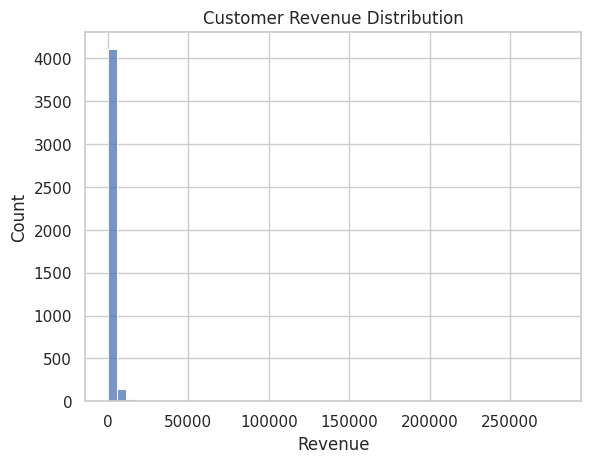

In [35]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()

sns.histplot(customer_revenue, bins=50)
plt.title("Customer Revenue Distribution")
plt.show()

In [36]:
top_share = top_customers.sum() / df['Revenue'].sum()

print(f"Top 10 customers contribute {top_share:.2%} of total revenue")

Top 10 customers contribute 17.26% of total revenue


In [ ]:
## A small number of customers contribute a disproportionate share of total revenue,
## indicating strong revenue concentration. This highlights both an opportunity for
## targeted retention strategies and a risk if high-value customers are lost.

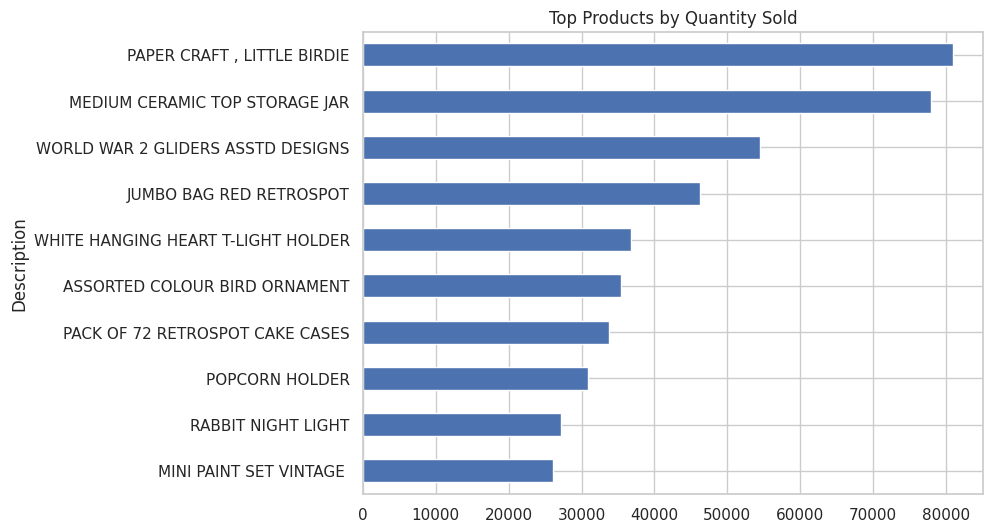

In [37]:
top_products_qty = df.groupby('Description')['Quantity'] \
                    .sum() \
                    .sort_values(ascending=False) \
                    .head(10)

top_products_qty.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Top Products by Quantity Sold")
plt.show()

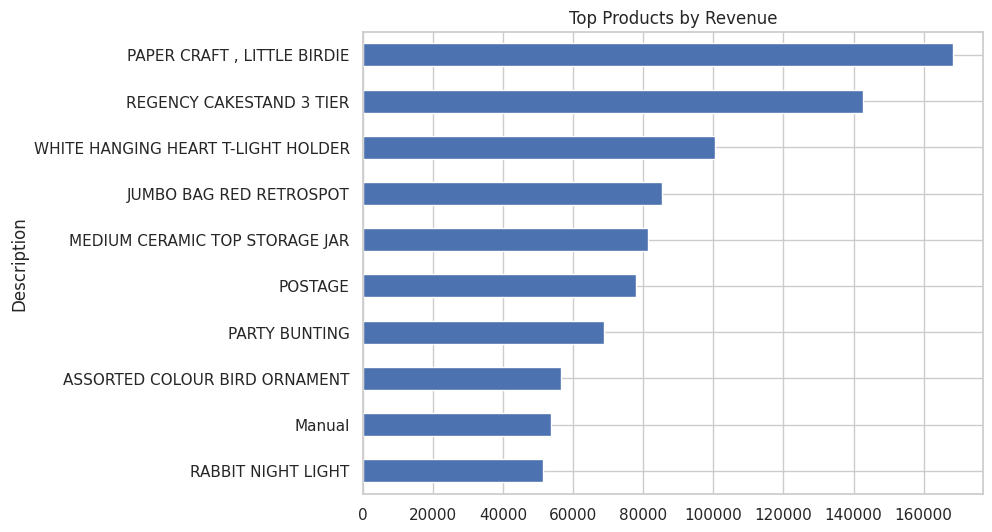

In [38]:
top_products_rev = df.groupby('Description')['Revenue'] \
                    .sum() \
                    .sort_values(ascending=False) \
                    .head(10)

top_products_rev.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Top Products by Revenue")
plt.show()

In [ ]:
## High-volume products differ from high-revenue products,
## indicating that pricing plays a significant role in total revenue generation.

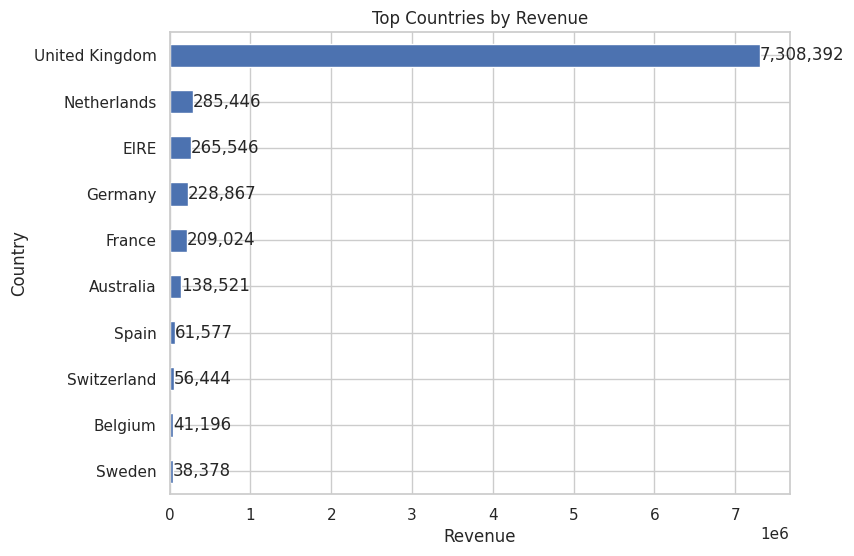

In [39]:
country_revenue = df.groupby('Country')['Revenue'] \
                    .sum() \
                    .sort_values(ascending=False) \
                    .head(10) \
                    .round(0)

fig, ax = plt.subplots(figsize=(8,6))

country_revenue.sort_values().plot(kind='barh', ax=ax)

for i, v in enumerate(country_revenue.sort_values()):
    ax.text(v, i, f"{int(v):,}", va='center')

ax.set_title("Top Countries by Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Country")

plt.show()

In [ ]:
## Revenue is heavily concentrated in the United Kingdom, indicating strong geographic dependence on a single market.

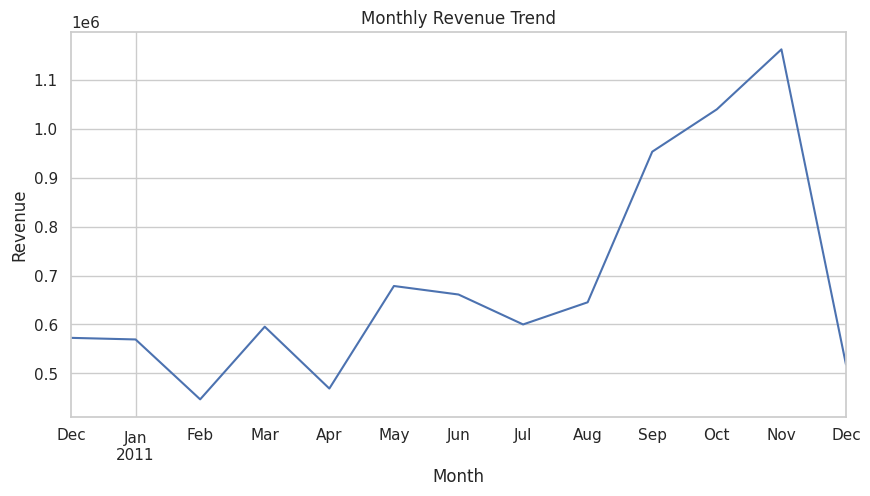

In [40]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
## Revenue trends over time indicate potential seasonality, which can be leveraged for forecasting and strategic planning.

In [ ]:
## Final EDA Summary

### Key Findings:
### - Revenue distribution is highly skewed with extreme outliers
### - A small number of customers contribute a large share of revenue
### - Sales are heavily concentrated in the United Kingdom
### - Certain products dominate both volume and revenue

### Data Issues:
### - Missing CustomerID reduces tracking capability
### - Negative quantities represent returns and must be handled
### - Outliers significantly affect analysis

### Business Insights:
### - High-value customers should be prioritized for retention
### - Heavy dependence on a single country presents risk
### - Geographic dependency presents potential business risk
### - Product demand is concentrated among key items